# `euler1d` — a guided tour

A finite-volume solver for the one-dimensional Euler equations, with an exact
Riemann solver to check it against.

This notebook is **generated and executed** by `scripts/build_demo_notebook.py`,
so every number and figure below is what the committed code produces. Run it
yourself with:

```bash
pip install -e ".[dev,notebook]"
python scripts/build_demo_notebook.py
```


## 1. What is available

Problems come with an exact solution; schemes are named combinations of a
numerical flux, a reconstruction and a time integrator.

In [1]:
import matplotlib.pyplot as plt

from euler1d import PRESETS, PROBLEMS, get_problem, l1_error, preset, solve

print("problems:", ", ".join(PROBLEMS))
print("schemes :", ", ".join(PRESETS))

problems: sod, lax, toro2, toro3, toro4, smooth
schemes : lax_friedrichs, local_lax_friedrichs, second_order_space, second_order_time, second_order_combined, hllc_muscl


## 2. The exact Riemann solver

Sod's problem has tabulated reference values in Toro's book
(*Riemann Solvers and Numerical Methods for Fluid Dynamics*, table 4.1):
$p_* = 0.30313$ and $u_* = 0.92745$. The solver finds the star pressure with a
Newton iteration on

$$f(p) = f_L(p, \mathbf{W}_L) + f_R(p, \mathbf{W}_R) + (u_R - u_L) = 0.$$

In [2]:
from euler1d import solve_star_state

sod = get_problem("sod")
star = solve_star_state(sod.left, sod.right)

print(f"wave pattern : {star.left_wave} | contact | {star.right_wave}")
print(f"p*           : {star.p:.5f}   (Toro: 0.30313)")
print(f"u*           : {star.u:.5f}   (Toro: 0.92745)")
print(f"converged in : {star.iterations} Newton iterations")
print("\nwave speeds:")
for name, speed in star.speeds.items():
    print(f"  {name:<12} S = {speed:+.5f}   x(t=0.2) = {0.5 + speed * 0.2:.4f}")

wave pattern : rarefaction | contact | shock
p*           : 0.30313   (Toro: 0.30313)
u*           : 0.92745   (Toro: 0.92745)
converged in : 4 Newton iterations

wave speeds:
  contact      S = +0.92745   x(t=0.2) = 0.6855
  left_head    S = -1.18322   x(t=0.2) = 0.2634
  left_tail    S = -0.07027   x(t=0.2) = 0.4859
  right_shock  S = +1.75216   x(t=0.2) = 0.8504


## 3. One run

Every solve takes a configuration and an initial condition, and returns a
`Solution` that knows how to give back primitive variables.

In [3]:
config = preset("hllc_muscl", nx=200, cfl=0.4)
solution = solve(config, sod.initial_condition)

print(config.describe())
print(f"reached t = {solution.t} in {solution.steps} steps")

rho_exact, u_exact, p_exact = sod.exact(solution.x, solution.t)
print(f"L1 error in density: {l1_error(solution.density, rho_exact, config.dx):.3e}")

hllc + MUSCL/mc + ssprk3
reached t = 0.2 in 219 steps
L1 error in density: 3.080e-03


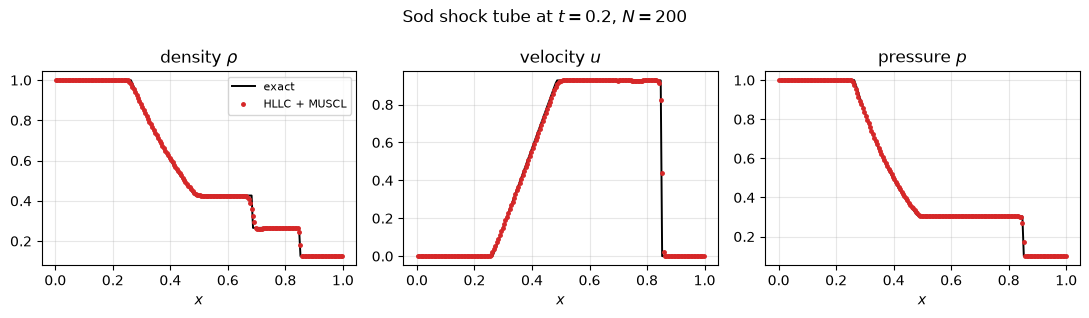

In [4]:
fig, axes = plt.subplots(1, 3, figsize=(11, 3.2))
panels = [
    ("density $\\rho$", solution.density, rho_exact),
    ("velocity $u$", solution.velocity, u_exact),
    ("pressure $p$", solution.pressure, p_exact),
]
for ax, (title, numeric, exact) in zip(axes, panels):
    ax.plot(solution.x, exact, "k-", lw=1.4, label="exact")
    ax.plot(solution.x, numeric, "o", ms=2.5, color="tab:red", label="HLLC + MUSCL")
    ax.set_title(title)
    ax.set_xlabel("$x$")
    ax.grid(alpha=0.3)
axes[0].legend(fontsize=8)
fig.suptitle("Sod shock tube at $t = 0.2$, $N = 200$")
fig.tight_layout()
plt.show()

## 4. Comparing the methods of the report

Note what the errors say: adding **Heun's method alone** barely helps, because
on a discontinuous problem the spatial truncation error dominates. Adding
**piecewise-linear reconstruction** is what pays.

In [5]:
rows = []
for name in PRESETS:
    cfg = preset(name, nx=200, cfl=0.4)
    sol = solve(cfg, sod.initial_condition)
    exact, _, _ = sod.exact(sol.x, sol.t)
    rows.append((PRESETS[name]["label"], l1_error(sol.density, exact, cfg.dx)))

width = max(len(label) for label, _ in rows)
reference = rows[0][1]
print(f"{'scheme':<{width}} {'L1(rho)':>11}   {'vs. LF':>8}")
print("-" * (width + 24))
for label, error in rows:
    print(f"{label:<{width}} {error:11.3e}   {reference / error:7.1f}x")

scheme                                L1(rho)     vs. LF
---------------------------------------------------------
Lax-Friedrichs                      3.274e-02       1.0x
Local Lax-Friedrichs                1.696e-02       1.9x
2nd order in space (MUSCL-minmod)   4.446e-03       7.4x
2nd order in time (Heun)            1.826e-02       1.8x
2nd order in space and time         5.678e-03       5.8x
HLLC + MUSCL-MC + SSP-RK3           3.080e-03      10.6x


## 5. Does it really achieve second order?

A shock caps every scheme at first order in $L^1$, so the design order has to be
measured on a smooth solution. Uniform pressure and velocity with a sinusoidal
density is an exact solution of the Euler system — the density is simply
advected — and it is periodic and infinitely smooth.

In [6]:
from euler1d import ConvergenceTable

smooth = get_problem("smooth")
resolutions = [25, 50, 100, 200, 400]
tables = []

for name in ["local_lax_friedrichs", "second_order_combined", "hllc_muscl"]:
    errors = []
    for nx in resolutions:
        cfg = preset(name, nx=nx, cfl=0.4, t_final=smooth.t_final,
                     boundary="periodic")
        sol = solve(cfg, smooth.initial_condition)
        exact, _, _ = smooth.exact(sol.x, sol.t)
        errors.append(l1_error(sol.density, exact, cfg.dx))
    table = ConvergenceTable(resolutions, errors, label=PRESETS[name]["label"])
    tables.append(table)
    print(f"{table.label}\n{table}\n")

Local Lax-Friedrichs
     N       L1 error    order
------------------------------
    25     1.7702e-01      --- 
    50     1.0624e-01     0.74
   100     5.8577e-02     0.86
   200     3.0781e-02     0.93
   400     1.5772e-02     0.96



2nd order in space and time
     N       L1 error    order
------------------------------
    25     3.9311e-02      --- 
    50     1.7402e-02     1.18
   100     5.0144e-03     1.80
   200     1.3894e-03     1.85
   400     3.7905e-04     1.87



HLLC + MUSCL-MC + SSP-RK3
     N       L1 error    order
------------------------------
    25     9.2043e-03      --- 
    50     2.6794e-03     1.78
   100     6.8280e-04     1.97
   200     1.7483e-04     1.97
   400     4.3421e-05     2.01



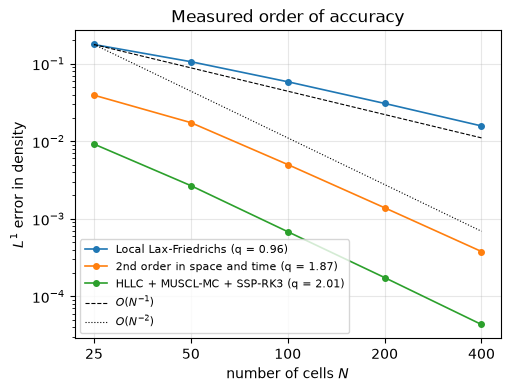

In [7]:
fig, ax = plt.subplots(figsize=(5.5, 4))
for table in tables:
    ax.loglog(table.resolutions, table.errors, "o-", lw=1.2, ms=4,
              label=f"{table.label} (q = {table.asymptotic_order:.2f})")
guide = [resolutions[0], resolutions[-1]]
e0 = tables[0].errors[0]
ax.loglog(guide, [e0 * (resolutions[0] / n) for n in guide], "k--", lw=0.8,
          label="$O(N^{-1})$")
ax.loglog(guide, [e0 * (resolutions[0] / n) ** 2 for n in guide], "k:", lw=0.8,
          label="$O(N^{-2})$")
ax.set_xticks(resolutions)
ax.set_xticks([], minor=True)
ax.set_xticklabels([str(n) for n in resolutions])
ax.set_xlabel("number of cells $N$")
ax.set_ylabel("$L^1$ error in density")
ax.set_title("Measured order of accuracy")
ax.grid(alpha=0.3)
ax.legend(fontsize=8)
plt.show()

## 6. The hard cases

Toro's **123 problem** pulls two rarefactions apart and leaves a near-vacuum
star region; a naive MUSCL reconstruction drives the pressure negative there
within a few steps. The package detects an inadmissible reconstructed state and
drops locally to first order, which is why the second-order schemes survive it.

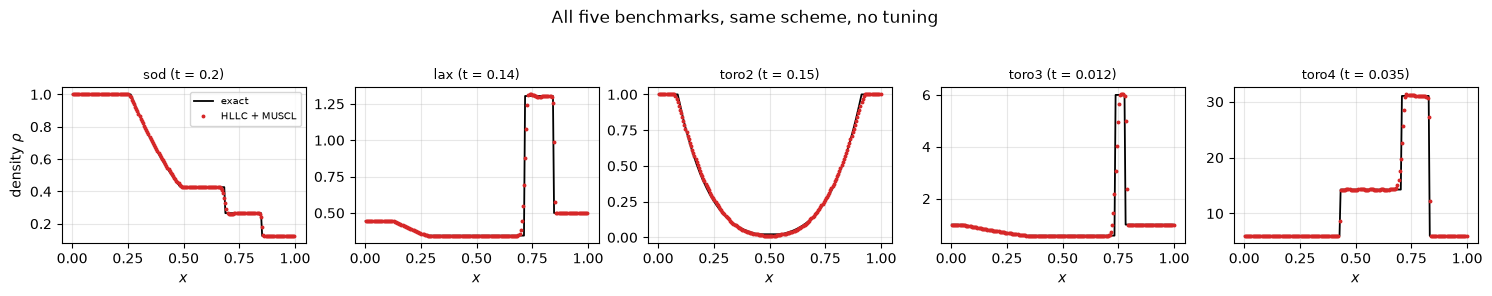

In [8]:
fig, axes = plt.subplots(1, 5, figsize=(15, 2.8))
for ax, name in zip(axes, ["sod", "lax", "toro2", "toro3", "toro4"]):
    problem = get_problem(name)
    cfg = preset("hllc_muscl", nx=200, cfl=0.4, x_min=problem.x_min,
                 x_max=problem.x_max, t_final=problem.t_final)
    sol = solve(cfg, problem.initial_condition)
    exact, _, _ = problem.exact(sol.x, sol.t)
    ax.plot(sol.x, exact, "k-", lw=1.3, label="exact")
    ax.plot(sol.x, sol.density, "o", ms=1.8, color="tab:red", label="HLLC + MUSCL")
    ax.set_title(f"{name} (t = {problem.t_final:g})", fontsize=9)
    ax.set_xlabel("$x$")
    ax.grid(alpha=0.3)
axes[0].set_ylabel(r"density $\rho$")
axes[0].legend(fontsize=7)
fig.suptitle("All five benchmarks, same scheme, no tuning", y=1.04)
fig.tight_layout()
plt.show()

## 7. Conservation

On a periodic domain the finite-volume update is a telescoping sum, so mass,
momentum and energy are conserved to machine precision. This is asserted in the
test suite for every scheme; here it is, visible.

In [9]:
cfg = preset("second_order_combined", nx=64, t_final=0.2, boundary="periodic")
initial = smooth.initial_condition(cfg.cell_centers)
sol = solve(cfg, initial)

before = initial.sum(axis=1) * cfg.dx
after = sol.conserved_totals()
for name, b, a in zip(["mass", "momentum", "energy"], before, after):
    print(f"{name:<9} before = {b:.15f}   after = {a:.15f}   drift = {abs(a - b):.2e}")

mass      before = 1.000000000000000   after = 1.000000000000000   drift = 0.00e+00
momentum  before = 1.000000000000000   after = 1.000000000000000   drift = 0.00e+00
energy    before = 3.000000000000000   after = 3.000000000000000   drift = 0.00e+00


---

Full results and figures: [`../docs/RESULTS.md`](../docs/RESULTS.md).
The command-line interface covers the same ground: `euler1d --help`.